# Graph-Based ASD Classification — Model Comparison
### ABIDE I | AAL-116 | GCN / GAT / GraphSAGE / GIN / BrainNetCNN
---
**포함 모델:**
| 모델 | 핵심 아이디어 |
|------|--------------|
| GCN | 기본 스펙트럼 그래프 컨볼루션 |
| GAT | 어텐션 기반 이웃 가중치 학습 |
| GraphSAGE | 이웃 샘플링 + 집계 함수 |
| GIN | 그래프 구조 구별력 최대화 |
| BrainNetCNN | fMRI FC 행렬 특화 CNN |


## Step 1: 라이브러리 임포트

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv, GINConv,
    global_mean_pool, global_add_pool, BatchNorm
)

print("PyTorch:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


PyTorch: 2.12.0+cpu
Device: cpu


## Step 2: ABIDE I 데이터 로드
기존 노트북에서 이미 다운로드한 데이터를 재사용합니다.

In [2]:
from nilearn.datasets import fetch_abide_pcp

DATA_DIR = './abide_data'

print("ABIDE I 로딩 중...")
abide1 = fetch_abide_pcp(
    data_dir=DATA_DIR,
    pipeline='cpac',
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=['rois_aal'],
    quality_checked=True,
    n_subjects=None,
    verbose=0
)

pheno1 = pd.DataFrame.from_records(abide1.phenotypic)

def compute_fc(timeseries_list):
    fc_matrices = []
    for ts in timeseries_list:
        ts = np.array(ts)
        if ts.ndim == 1 or ts.shape[1] != 116:
            fc_matrices.append(None)
            continue
        fc = np.corrcoef(ts.T)
        np.fill_diagonal(fc, 0)
        fc_matrices.append(fc)
    return fc_matrices

fc1 = compute_fc(abide1.rois_aal)
valid_mask = [f is not None for f in fc1]
fc_all    = [f for f, v in zip(fc1, valid_mask) if v]
pheno_all = pheno1[valid_mask].reset_index(drop=True)
labels_all = (pheno_all['DX_GROUP'].values == 1).astype(int)
ages_all   = pheno_all['AGE_AT_SCAN'].values.astype(float)

print(f"유효 피험자: {len(fc_all)}")
print(f"ASD: {labels_all.sum()}, TC: {(labels_all==0).sum()}")
print(f"연령 범위: {ages_all.min():.1f} ~ {ages_all.max():.1f}")


ABIDE I 로딩 중...
유효 피험자: 871
ASD: 403, TC: 468
연령 범위: 6.5 ~ 58.0


## Step 3: 그래프 데이터셋 구성
Fisher-Z 변환 + Top-K 희소화

In [3]:
def build_graph(fc, label, top_k=20):
    fc = np.nan_to_num(fc, nan=0.0, posinf=0.0, neginf=0.0)
    fc_z = np.arctanh(np.clip(fc, -0.99, 0.99))  # Fisher-Z

    n = fc_z.shape[0]
    edge_index, edge_weight = [], []
    for i in range(n):
        row = np.abs(fc_z[i])
        top_j = np.argsort(row)[-top_k:]
        for j in top_j:
            if i != j:
                edge_index.append([i, j])
                edge_weight.append(fc_z[i, j])

    edge_index  = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)
    x = torch.tensor(fc_z, dtype=torch.float)        # (116, 116)
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)

dataset = [build_graph(fc, lab) for fc, lab in zip(fc_all, labels_all)]
print(f"그래프 수: {len(dataset)}")
print(f"노드 수: {dataset[0].num_nodes}, 엣지 수: {dataset[0].num_edges}")
print(f"노드 특징 shape: {dataset[0].x.shape}")

# Sanity check
print(f"\nFC 값 범위: {dataset[0].x.min():.3f} ~ {dataset[0].x.max():.3f}")


그래프 수: 871
노드 수: 116, 엣지 수: 2320
노드 특징 shape: torch.Size([116, 116])

FC 값 범위: -0.520 ~ 1.877


## Step 4: 모델 정의
### 4-1. GCN

In [4]:
class GCNModel(nn.Module):
    """기본 GCN (Kipf & Welling, 2017)"""
    def __init__(self, in_ch=116, hidden=64, num_classes=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.bn1   = BatchNorm(hidden)
        self.bn2   = BatchNorm(hidden)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden, 32)
        self.fc2   = nn.Linear(32, num_classes)

    def forward(self, data):
        x, ei, ew, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = F.relu(self.bn1(self.conv1(x, ei, ew)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.conv2(x, ei, ew)))
        x = self.drop(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


### 4-2. GAT

In [5]:
class GATModel(nn.Module):
    """GAT: Graph Attention Network (Veličković et al., 2018)"""
    def __init__(self, in_ch=116, hidden=32, heads=4, num_classes=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_ch,         hidden, heads=heads,   dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden*heads,   hidden, heads=1,       dropout=dropout, concat=False)
        self.bn1   = BatchNorm(hidden*heads)
        self.bn2   = BatchNorm(hidden)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden, 32)
        self.fc2   = nn.Linear(32, num_classes)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.bn1(self.conv1(x, ei)))
        x = self.drop(x)
        x = F.elu(self.bn2(self.conv2(x, ei)))
        x = self.drop(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


### 4-3. GraphSAGE

In [6]:
class GraphSAGEModel(nn.Module):
    """GraphSAGE (Hamilton et al., 2017) — inductive 학습"""
    def __init__(self, in_ch=116, hidden=64, num_classes=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_ch,   hidden)
        self.conv2 = SAGEConv(hidden,  hidden)
        self.bn1   = BatchNorm(hidden)
        self.bn2   = BatchNorm(hidden)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden, 32)
        self.fc2   = nn.Linear(32, num_classes)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, ei)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = self.drop(x)
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


### 4-4. GIN

In [7]:
class GINModel(nn.Module):
    """GIN: Graph Isomorphism Network (Xu et al., 2019) — 구조 구별력 최대"""
    def __init__(self, in_ch=116, hidden=64, num_classes=2, dropout=0.5):
        super().__init__()

        def mlp(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f), nn.BatchNorm1d(out_f), nn.ReLU(),
                nn.Linear(out_f, out_f)
            )

        self.conv1 = GINConv(mlp(in_ch, hidden),  train_eps=True)
        self.conv2 = GINConv(mlp(hidden, hidden),  train_eps=True)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden * 2, 64)   # concat layer1+layer2
        self.fc2   = nn.Linear(64, num_classes)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        h1 = F.relu(self.conv1(x, ei))
        h1 = self.drop(h1)
        h2 = F.relu(self.conv2(h1, ei))
        h2 = self.drop(h2)
        # multi-scale pooling
        out = torch.cat([global_add_pool(h1, batch),
                         global_add_pool(h2, batch)], dim=1)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        return self.fc2(out)


### 4-5. BrainNetCNN

In [8]:
class BrainNetCNN(nn.Module):
    """
    BrainNetCNN (Kawahara et al., 2017)
    FC 행렬을 2D 이미지로 보고 Edge-to-Edge, Edge-to-Node, Node-to-Graph 레이어 적용.
    PyG DataLoader와 함께 쓸 수 있도록 fc_matrix를 x로 받음.
    """
    def __init__(self, n_rois=116, num_classes=2, dropout=0.5):
        super().__init__()
        # Edge-to-Edge (E2E): 1×n and n×1 convolutions
        self.e2e_row = nn.Conv2d(1, 32, (1, n_rois))   # row-wise
        self.e2e_col = nn.Conv2d(1, 32, (n_rois, 1))   # col-wise

        # Edge-to-Node (E2N): combine row & col
        self.e2n = nn.Conv2d(32, 64, (1, 1))

        # Node-to-Graph (N2G): global
        self.n2g = nn.Conv2d(64, 256, (n_rois, 1))

        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(256, 128)
        self.fc2   = nn.Linear(128, num_classes)
        self.n_rois = n_rois

    def forward(self, data):
        # data.x shape: (batch_nodes, 116) → reshape to (batch, 1, 116, 116)
        batch_size = data.batch.max().item() + 1
        x = data.x.view(batch_size, 1, self.n_rois, self.n_rois)

        # E2E
        r = F.leaky_relu(self.e2e_row(x))     # (B, 32, 116, 1)
        c = F.leaky_relu(self.e2e_col(x))     # (B, 32, 1, 116)
        # Broadcast and combine
        e2e = r.expand(-1,-1,-1,self.n_rois) + c.expand(-1,-1,self.n_rois,-1)

        # E2N
        e2n = F.leaky_relu(self.e2n(e2e))     # (B, 64, 116, 116)
        e2n = F.max_pool2d(e2n, (1, self.n_rois))  # (B, 64, 116, 1)

        # N2G
        n2g = F.leaky_relu(self.n2g(e2n))     # (B, 256, 1, 1)
        n2g = n2g.view(batch_size, -1)         # (B, 256)

        out = self.drop(n2g)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        return self.fc2(out)


## Step 5: 학습 함수 정의

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = model(data)
        loss = criterion(out, data.y.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, trues, probs = [], [], []
    for data in loader:
        data = data.to(device)
        out  = model(data)
        prob = F.softmax(out, dim=1)[:, 1]
        pred = out.argmax(dim=1)
        preds.extend(pred.cpu().numpy())
        trues.extend(data.y.squeeze().cpu().numpy())
        probs.extend(prob.cpu().numpy())

    probs = np.nan_to_num(np.array(probs), nan=0.5)
    trues = np.array(trues)
    preds = np.array(preds)

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, zero_division=0)
    auc = roc_auc_score(trues, probs) if len(set(trues)) > 1 else 0.5
    return acc, f1, auc


def run_cv(model_class, model_kwargs, dataset, labels,
           n_splits=5, epochs=100, lr=1e-3, batch_size=16,
           weight_decay=1e-4, model_name="Model"):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    print(f"\n{'='*55}")
    print(f"  {model_name} — {n_splits}-Fold CV")
    print(f"{'='*55}")

    for fold, (tr_idx, te_idx) in enumerate(skf.split(dataset, labels)):
        train_data = [dataset[i] for i in tr_idx]
        test_data  = [dataset[i] for i in te_idx]

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

        model = model_class(**model_kwargs).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        # Class weights
        n_asd = labels[tr_idx].sum()
        n_tc  = len(tr_idx) - n_asd
        w = torch.tensor([n_asd/len(tr_idx), n_tc/len(tr_idx)], dtype=torch.float).to(device)
        criterion = nn.CrossEntropyLoss(weight=w)

        best_acc, best_metrics = 0, (0, 0, 0)
        for epoch in range(1, epochs+1):
            loss = train_epoch(model, train_loader, optimizer, criterion)
            scheduler.step()
            if epoch % 20 == 0:
                acc, f1, auc = evaluate(model, test_loader)
                if acc > best_acc:
                    best_acc = acc
                    best_metrics = (acc, f1, auc)

        acc, f1, auc = evaluate(model, test_loader)
        # Use best or final, whichever is better
        if acc > best_metrics[0]:
            best_metrics = (acc, f1, auc)

        fold_results.append({'fold': fold+1, 'acc': best_metrics[0],
                             'f1': best_metrics[1], 'auc': best_metrics[2]})
        print(f"  Fold {fold+1}: Acc={best_metrics[0]:.4f}, F1={best_metrics[1]:.4f}, AUC={best_metrics[2]:.4f}")

    df = pd.DataFrame(fold_results)
    print(f"  ─── 평균: Acc={df['acc'].mean():.4f}±{df['acc'].std():.4f} | "
          f"F1={df['f1'].mean():.4f} | AUC={df['auc'].mean():.4f}")
    return df


## Step 6: 전체 모델 학습 및 비교

In [10]:
labels_np = np.array([d.y.item() for d in dataset])

model_configs = [
    ("GCN",         GCNModel,       {"in_ch": 116, "hidden": 64}),
    ("GAT",         GATModel,       {"in_ch": 116, "hidden": 32, "heads": 4}),
    ("GraphSAGE",   GraphSAGEModel, {"in_ch": 116, "hidden": 64}),
    ("GIN",         GINModel,       {"in_ch": 116, "hidden": 64}),
    ("BrainNetCNN", BrainNetCNN,    {"n_rois": 116}),
]

all_results = {}

for model_name, model_class, model_kwargs in model_configs:
    df = run_cv(
        model_class  = model_class,
        model_kwargs = model_kwargs,
        dataset      = dataset,
        labels       = labels_np,
        n_splits     = 5,
        epochs       = 100,
        lr           = 3e-3,
        batch_size   = 16,
        model_name   = model_name
    )
    all_results[model_name] = df

print("\n✅ 모든 모델 학습 완료!")



  GCN — 5-Fold CV
  Fold 1: Acc=0.5371, F1=0.0000, AUC=0.5000
  Fold 2: Acc=0.5345, F1=0.0000, AUC=0.5000
  Fold 3: Acc=0.5345, F1=0.0000, AUC=0.5000
  Fold 4: Acc=0.5402, F1=0.0000, AUC=0.5000
  Fold 5: Acc=0.5402, F1=0.0000, AUC=0.5000
  ─── 평균: Acc=0.5373±0.0029 | F1=0.0000 | AUC=0.5000

  GAT — 5-Fold CV
  Fold 1: Acc=0.6171, F1=0.6257, AUC=0.6790
  Fold 2: Acc=0.6782, F1=0.6585, AUC=0.7324
  Fold 3: Acc=0.5690, F1=0.5342, AUC=0.6028
  Fold 4: Acc=0.6322, F1=0.6235, AUC=0.6739
  Fold 5: Acc=0.6437, F1=0.5634, AUC=0.6440
  ─── 평균: Acc=0.6280±0.0399 | F1=0.6011 | AUC=0.6664

  GraphSAGE — 5-Fold CV
  Fold 1: Acc=0.6286, F1=0.6734, AUC=0.6911
  Fold 2: Acc=0.6034, F1=0.5660, AUC=0.6211
  Fold 3: Acc=0.5805, F1=0.4427, AUC=0.5842
  Fold 4: Acc=0.6264, F1=0.4882, AUC=0.6660
  Fold 5: Acc=0.5862, F1=0.3571, AUC=0.5941
  ─── 평균: Acc=0.6050±0.0222 | F1=0.5055 | AUC=0.6313

  GIN — 5-Fold CV
  Fold 1: Acc=0.5371, F1=0.0000, AUC=0.5000
  Fold 2: Acc=0.6379, F1=0.5714, AUC=0.6645
  Fold 3: A

## Step 7: 결과 요약 테이블

In [11]:
rows = []
for name, df in all_results.items():
    rows.append({
        'Model':    name,
        'Accuracy': f"{df['acc'].mean():.4f} ± {df['acc'].std():.4f}",
        'F1 Score': f"{df['f1'].mean():.4f} ± {df['f1'].std():.4f}",
        'AUC':      f"{df['auc'].mean():.4f} ± {df['auc'].std():.4f}",
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("\n===== Model Comparison (ABIDE I, AAL-116, 5-Fold CV) =====")
print(summary_df.to_string())
summary_df.to_csv('model_comparison_results.csv')
print("\nSaved: model_comparison_results.csv")



===== Model Comparison (ABIDE I, AAL-116, 5-Fold CV) =====
                    Accuracy         F1 Score              AUC
Model                                                         
GCN          0.5373 ± 0.0029  0.0000 ± 0.0000  0.5000 ± 0.0000
GAT          0.6280 ± 0.0399  0.6011 ± 0.0508  0.6664 ± 0.0478
GraphSAGE    0.6050 ± 0.0222  0.5055 ± 0.1205  0.6313 ± 0.0460
GIN          0.5580 ± 0.0447  0.1143 ± 0.2556  0.5329 ± 0.0736
BrainNetCNN  0.5924 ± 0.0184  0.5544 ± 0.0430  0.5977 ± 0.0487

Saved: model_comparison_results.csv


## Step 8: 결과 시각화

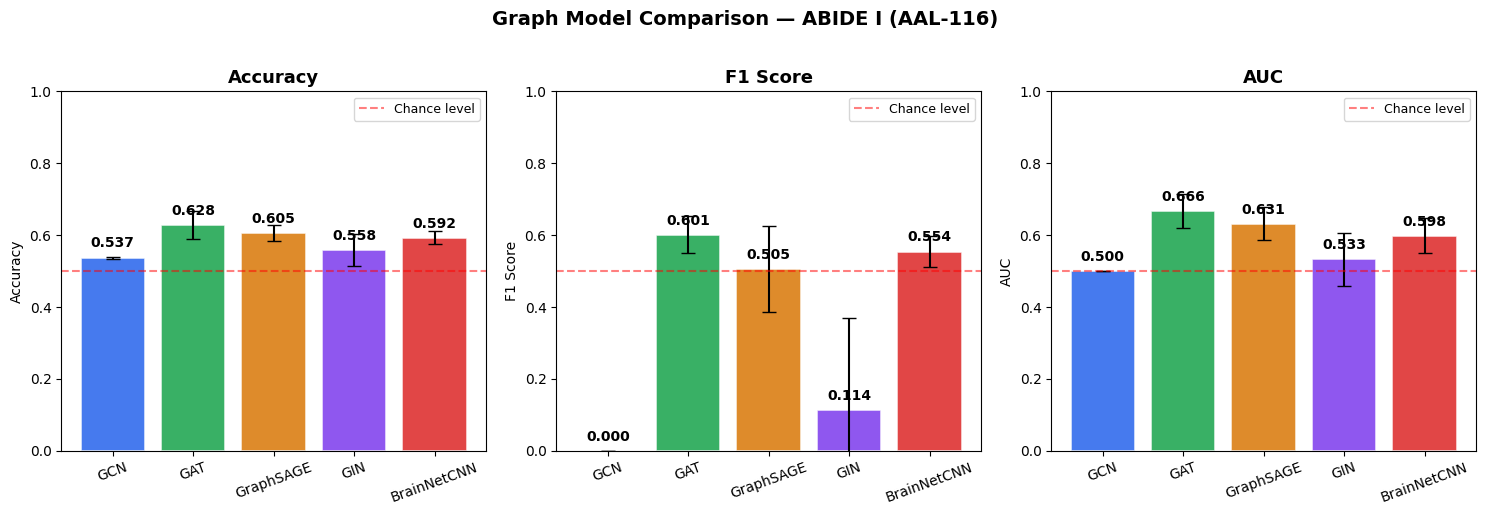

Saved: model_comparison_plot.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics  = ['acc', 'f1', 'auc']
titles   = ['Accuracy', 'F1 Score', 'AUC']
colors   = ['#2563EB', '#16A34A', '#D97706', '#7C3AED', '#DC2626']

for ax, metric, title in zip(axes, metrics, titles):
    means = [all_results[m][metric].mean() for m in all_results]
    stds  = [all_results[m][metric].std()  for m in all_results]
    names = list(all_results.keys())

    bars = ax.bar(names, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim(0, 1.0)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance level')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)

    # Value labels on bars
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Graph Model Comparison — ABIDE I (AAL-116)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_plot.png")


## Step 9: Fold별 분포 (Box Plot)

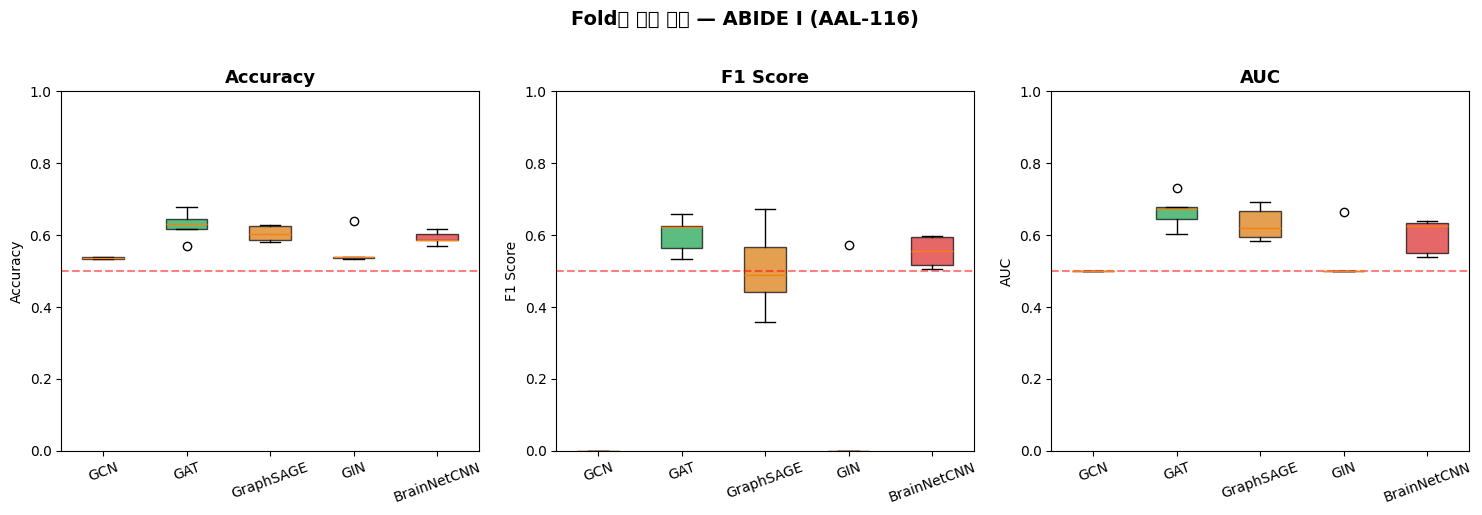

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title in zip(axes, ['acc', 'f1', 'auc'], ['Accuracy', 'F1 Score', 'AUC']):
    data_plot = [all_results[m][metric].values for m in all_results]
    bp = ax.boxplot(data_plot, patch_artist=True, labels=list(all_results.keys()))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim(0, 1.0)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Fold별 성능 분포 — ABIDE I (AAL-116)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
